# FINESST WASP-107 b disequilibrium-chemistry motivation

This notebook creates the three-panel proposal figure comparing the published JWST/NIRSpec transmission spectrum and ATMO best-fitting spectrum with the equilibrium and disequilibrium CH$_4$/SO$_2$ abundance profiles reported by Sing et al. (2024).

## Important provenance note

This notebook **does not run a retrieval, equilibrium calculation, photochemical model, or radiative-transfer model**. It plots:

- the published 576-point WASP-107 b spectrum;
- a documented digitization of the published ATMO full-model curve from Sing et al. (2024), Figure 2;
- the supplied equilibrium CH$_4$ profile;
- the published disequilibrium CH$_4$ and SO$_2$ profiles;
- the ATMO free-retrieval abundance constraints reported in Extended Data Table 2.

The column previously labeled as equilibrium SO$_2$ was confirmed to be **equilibrium CO$_2$** and is never plotted. The equilibrium SO$_2$ curve lies below the published Figure 3 plotting floor of $\\log_{10}(\\mathrm{VMR})=-8$. Panel (c) therefore does not invent a profile. Its optional enhancement arrow uses only that published plotting floor and the retrieved median, so it is explicitly a graphical lower bound rather than a tabulated equilibrium abundance.

In [1]:
#***** Imports and portable path setup *****#
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from IPython.display import display


def locate_finesst_directory():
    candidates = [Path.cwd().resolve()]
    for candidate in list(candidates):
        candidates.extend(candidate.parents)
    for candidate in candidates:
        if candidate.name == 'FINESST' and (candidate.parent / 'data').is_dir():
            return candidate
        if (candidate / 'run' / 'FINESST').is_dir():
            return candidate / 'run' / 'FINESST'
    raise FileNotFoundError('Could not locate POSEIDON/run/FINESST.')


FINESST_DIRECTORY = locate_finesst_directory()
RUN_DIRECTORY = FINESST_DIRECTORY.parent

if str(FINESST_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(FINESST_DIRECTORY))

from FINESST_WASP107b_Disequilibrium_Motivation_Plot import (
    default_config,
    load_products,
    make_figure,
    save_figure,
)

config = default_config(RUN_DIRECTORY)

## Input and output paths

All paths are portable and rooted at POSEIDON/run. The official-paper image and digitized spectrum are retained with checksums and digitization metadata.

In [2]:
#***** Published inputs and FINESST output directory *****#
DATA_DIRECTORY = RUN_DIRECTORY / 'data' / 'FINESST_26' / 'Figure_2'
OUTPUT_DIRECTORY = (
    RUN_DIRECTORY / 'POSEIDON_output' / 'WASP-107b' / 'plots' / 'FINESST'
)

config.paths.observed_spectrum_path = (
    DATA_DIRECTORY / 'Sing_2024_Fig2_WASP107b_transit_spec_data.csv'
)
config.paths.digitized_model_path = (
    DATA_DIRECTORY / 'Sing_2024_Fig2_ATMO_full_model_digitized.csv'
)
config.paths.digitization_metadata_path = (
    DATA_DIRECTORY / 'Sing_2024_Fig2_ATMO_full_model_digitization_metadata.json'
)
config.paths.disequilibrium_profiles_path = (
    DATA_DIRECTORY / 'Sing_2024_Fig3_neq_chem_vmr.csv'
)
config.paths.equilibrium_profiles_path = (
    DATA_DIRECTORY / 'equilibrium_SO2_CH4_values.csv'
)
config.paths.jwst_pressure_constraints_path = (
    DATA_DIRECTORY / 'SO2_CH4_JWST_pressure_constraints_on_data_points.csv'
)
config.paths.paper_path = DATA_DIRECTORY / 'Sing_2024_WASP107b_paper.pdf'
config.paths.output_directory = OUTPUT_DIRECTORY

## Colors

These defaults carry over the color-blind-safe palette used in the FINESST retrieval-comparison figure. Every plotted category can be changed here.

In [3]:
#***** Figure palette *****#
OBSERVED_COLOR = '#262626'
PUBLISHED_MODEL_COLOR = "#AF0000"
EQUILIBRIUM_COLOR = '#605D5D'
DISEQUILIBRIUM_COLOR = '#E3770B'
RETRIEVAL_COLOR = '#000000'
CH4_BAND_COLOR = "#E5530F"
SO2_BAND_COLOR = "#19B581"
H2O_BAND_COLOR = '#0072B2'
CO2_BAND_COLOR = '#CC79A7'
CO_BAND_COLOR = '#6A3D9A'

config.style.observed_color = OBSERVED_COLOR
config.style.model_color = PUBLISHED_MODEL_COLOR
config.style.equilibrium_color = EQUILIBRIUM_COLOR
config.style.disequilibrium_color = DISEQUILIBRIUM_COLOR
config.style.retrieved_color = RETRIEVAL_COLOR
config.style.ch4_band_color = CH4_BAND_COLOR
config.style.so2_band_color = SO2_BAND_COLOR
config.style.h2o_band_color = H2O_BAND_COLOR
config.style.co2_band_color = CO2_BAND_COLOR
config.style.co_band_color = CO_BAND_COLOR

## Overall figure size and panel spacing

The requested default canvas is 7.5 by 4.8 inches. The left/right panel allocation, margins, and both inter-panel spacings are independently editable.

In [4]:
#***** Global dimensions, margins, and inter-panel spacing *****#
FIGURE_WIDTH_INCHES = 11
FIGURE_HEIGHT_INCHES = 4.8

# Panel (a) occupies the full left column; panels (b)/(c) share the right.
COLUMN_WIDTH_RATIOS = (0.7, 0.3)
CHEMISTRY_HEIGHT_RATIOS = (1.0, 1.0)

HORIZONTAL_PANEL_SPACE = 0.18
VERTICAL_CHEMISTRY_PANEL_SPACE = 0.34

LEFT_MARGIN = 0.015
RIGHT_MARGIN = 0.985
BOTTOM_MARGIN = 0.015
TOP_MARGIN = 0.985

config.layout.figure_width_inches = FIGURE_WIDTH_INCHES
config.layout.figure_height_inches = FIGURE_HEIGHT_INCHES
config.layout.width_ratios = COLUMN_WIDTH_RATIOS
config.layout.height_ratios = CHEMISTRY_HEIGHT_RATIOS
config.layout.horizontal_space = HORIZONTAL_PANEL_SPACE
config.layout.vertical_space = VERTICAL_CHEMISTRY_PANEL_SPACE
config.layout.left_margin = LEFT_MARGIN
config.layout.right_margin = RIGHT_MARGIN
config.layout.bottom_margin = BOTTOM_MARGIN
config.layout.top_margin = TOP_MARGIN

## Typography, ticks, and axis boxes

The default is DejaVu Serif, matching the existing FINESST figure. Set USE_SANS_SERIF to True to use DejaVu Sans. Font sizes are scaled from the earlier 12-inch figure to the requested 7.5-inch canvas.

In [5]:
#***** POSEIDON-style typography and axes *****#
USE_SANS_SERIF = False
SERIF_FONT = 'DejaVu Serif'
SANS_SERIF_FONT = 'DejaVu Sans'

AXIS_LABEL_FONTSIZE = 16
TICK_LABEL_FONTSIZE = 11
LEGEND_FONTSIZE = 10
ANNOTATION_FONTSIZE = 8.5
PANEL_LABEL_FONTSIZE = 13

AXIS_BOX_LINEWIDTH = 0.8
MAJOR_TICK_LENGTH = 4.0
MINOR_TICK_LENGTH = 2.2
SPECTRUM_LINEWIDTH = 0.95
ERRORBAR_LINEWIDTH = 0.9

config.style.use_sans_serif = USE_SANS_SERIF
config.style.serif_font = SERIF_FONT
config.style.sans_serif_font = SANS_SERIF_FONT
config.style.axis_label_size = AXIS_LABEL_FONTSIZE
config.style.tick_label_size = TICK_LABEL_FONTSIZE
config.style.legend_size = LEGEND_FONTSIZE
config.style.annotation_size = ANNOTATION_FONTSIZE
config.style.panel_label_size = PANEL_LABEL_FONTSIZE
config.style.tick_width = AXIS_BOX_LINEWIDTH
config.style.tick_length = MAJOR_TICK_LENGTH
config.style.minor_tick_length = MINOR_TICK_LENGTH
config.style.line_width = SPECTRUM_LINEWIDTH
config.style.errorbar_line_width = ERRORBAR_LINEWIDTH

## Panels (a)/(b): equal-size full and zoomed spectra

Panels (a) and (b) now have identical figure-coordinate width and height, forming the left column of a 2×2-style layout. Panel (a) shows the complete 2.70–5.18 $\mu$m NIRSpec spectrum and published ATMO fit; panel (b) preserves the focused 3.10–4.20 $\mu$m CH$_4$/SO$_2$ view below it.

A single vertical label is centered across panels (a)/(b), and one horizontal label is centered below panel (b). Their sizes default to the panel-(a) axis-label size and remain independently editable. `indicate_inset_zoom` draws a bounded rectangle around panel (b)'s exact x/y domain and all four corresponding corner connectors.

In [6]:
#***** Panel (a) full-spectrum and zoomed-inset controls *****#
SPECTRUM_X_LABEL = r'Wavelength ($\mu$m)'
SPECTRUM_Y_LABEL = r'Planet-to-star radius ratio ($R_p/R_s$)'

# Parent axis: complete published NIRSpec wavelength range.
OVERALL_SPECTRUM_X_LIMITS = (2.70, 5.18)
OVERALL_SPECTRUM_Y_LIMITS = None
OVERALL_SPECTRUM_AXIS_LABEL_FONTSIZE = 16.0
OVERALL_SPECTRUM_TICK_LABEL_FONTSIZE = TICK_LABEL_FONTSIZE

# Shared labels replace duplicate x/y labels on panels (a) and (b).
USE_SHARED_SPECTRUM_AXIS_LABELS = True
SHARED_SPECTRUM_X_LABEL_FONTSIZE = OVERALL_SPECTRUM_AXIS_LABEL_FONTSIZE
SHARED_SPECTRUM_Y_LABEL_FONTSIZE = OVERALL_SPECTRUM_AXIS_LABEL_FONTSIZE
SHARED_SPECTRUM_X_LABEL_PAD_FIGURE = 0.065
SHARED_SPECTRUM_Y_LABEL_PAD_FIGURE = 0.055

# Inset axis: this preserves the previous chemistry-focused panel (a).
SHOW_ZOOMED_SPECTRUM_INSET = True
INSET_WAVELENGTH_PRESET = 'chemistry_focus'  # 'chemistry_focus', 'full', or 'custom'
INSET_WAVELENGTH_PRESETS = {
    'chemistry_focus': (3.10, 4.20),
    'full': (2.70, 5.18),
}
CUSTOM_INSET_X_LIMITS = (3.10, 4.20)
if INSET_WAVELENGTH_PRESET == 'custom':
    INSET_SPECTRUM_X_LIMITS = CUSTOM_INSET_X_LIMITS
elif INSET_WAVELENGTH_PRESET in INSET_WAVELENGTH_PRESETS:
    INSET_SPECTRUM_X_LIMITS = INSET_WAVELENGTH_PRESETS[INSET_WAVELENGTH_PRESET]
else:
    raise ValueError(
        "INSET_WAVELENGTH_PRESET must be 'chemistry_focus', 'full', or 'custom'."
    )
# Leave this as None with AUTO_INSET_Y_LIMITS=True for a data-driven zoom.
INSET_SPECTRUM_Y_LIMITS = None
AUTO_INSET_Y_LIMITS = True
INSET_Y_PADDING_FRACTION = 0.05

# The parent is shortened at the top of its original GridSpec allocation.
SHRINK_OVERALL_FOR_EXTERNAL_INSET = True
OVERALL_AXIS_HEIGHT_FRACTION = 0.44

# (left, bottom, width, height), in fractions of panel (a). Width=height=1
# makes panel (b) exactly the same dimensions; negative bottom places it below.
INSET_AXES_BOUNDS = (0.0, -1.18, 1.0, 1.0)
INSET_FACE_COLOR = 'white'
INSET_FACE_COLOR_ALPHA = 0.96
INSET_ZORDER = 10
INSET_AXIS_LABEL_FONTSIZE = 11.0
INSET_TICK_LABEL_FONTSIZE = TICK_LABEL_FONTSIZE
INSET_MOLECULAR_LABEL_FONTSIZE = 8.0

# Panel identifiers are independently editable here.
SPECTRUM_PANEL_LABEL = '(a)'
INSET_PANEL_LABEL = '(b)'
CH4_PANEL_LABEL = '(c)'
SO2_PANEL_LABEL = '(d)'

SHOW_INSET_ZOOM_INDICATOR = True
SHOW_ALL_INSET_ZOOM_CONNECTORS = True
INSET_ZOOM_INDICATOR_KWARGS = {
    'edgecolor': '#555555',
    'linewidth': 0.8,
    'alpha': 0.75,
    'zorder': 9,
}

# Data and model styling shared by the parent and inset axes.
DATA_N_WAVELENGTH_BINS = None
SHOW_DATA_BIN_WIDTHS = False
SHOW_SPECTRUM_MINOR_TICKS = True
DATA_LABEL = 'JWST NIRSpec'
MODEL_LABEL = r'Sing et al. (2024) $\tt{ATMO}$ fit'
DATA_MARKER = 'o'
DATA_MARKER_SIZE = 2.4
DATA_MARKER_FACE_COLOR = 'white'
DATA_ALPHA = 0.90
DATA_ZORDER = 5
MODEL_LINESTYLE = '-'
MODEL_LINEWIDTH = 0.95
MODEL_ZORDER = 4

# Full-spectrum feature regions. Customize ranges independently in microns.
SHOW_OVERALL_MOLECULAR_BANDS = True
OVERALL_MOLECULAR_BANDS = {
    'H2O': (2.70, 3.18),
    'CH4': (3.285, 3.355),
    'SO2': (3.95, 4.10),
    'CO2': (4.22, 4.43),
    'CO': (4.55, 4.95),
}
OVERALL_MOLECULAR_LABELS = {
    'H2O': r'H$_2$O',
    'CH4': r'CH$_4$',
    'SO2': r'SO$_2$',
    'CO2': r'CO$_2$',
    'CO': 'CO',
}
# Colors are set independently in the Figure palette cell above.
OVERALL_MOLECULAR_BAND_OPACITY = {
    'H2O': 0.11,
    'CH4': 0.11,
    'SO2': 0.11,
    'CO2': 0.11,
    'CO': 0.11,
}
OVERALL_MOLECULAR_BAND_FALLBACK_OPACITY = 0.11
OVERALL_MOLECULAR_BAND_ZORDER = 0
OVERALL_MOLECULAR_LABEL_Y_AXES = 0.965
# Override individual label heights here, e.g. {'CO2': 0.90}.
OVERALL_MOLECULAR_LABEL_Y_AXES_BY_SPECIES = {}
OVERALL_MOLECULAR_LABEL_FONTSIZE = 10.0
OVERALL_MOLECULAR_LABEL_FONTWEIGHT = 'bold'

# Inset feature regions: the exact CH4/SO2 choices from the previous panel (a).
SHOW_INSET_CH4_SO2_BANDS = True
INSET_MOLECULAR_BANDS = {
    'CH4': (3.285, 3.355),
    'SO2': (3.95, 4.10),
}
INSET_MOLECULAR_LABELS = {
    'CH4': r'CH$_4$',
    'SO2': r'SO$_2$',
}
INSET_MOLECULAR_BAND_OPACITY = {
    'CH4': 0.16,
    'SO2': 0.16,
}
INSET_MOLECULAR_BAND_FALLBACK_OPACITY = 0.16
INSET_MOLECULAR_BAND_ZORDER = 0
INSET_MOLECULAR_LABEL_Y_AXES = 0.965
INSET_MOLECULAR_LABEL_FONTWEIGHT = 'bold'

SHOW_OVERALL_SPECTRUM_LEGEND = False
SHOW_INSET_SPECTRUM_LEGEND = True
OVERALL_SPECTRUM_LEGEND_KWARGS = {
    'loc': 'upper right',
    'frameon': False,
    'ncol': 1,
    'handlelength': 1.8,
    'handletextpad': 0.5,
}
INSET_SPECTRUM_LEGEND_KWARGS = {
    'loc': 'upper center',
    'frameon': False,
    'ncol': 1,
    'handlelength': 1.8,
    'handletextpad': 0.5,
}

config.spectrum.x_label = SPECTRUM_X_LABEL
config.spectrum.y_label = SPECTRUM_Y_LABEL
config.spectrum.x_limits = OVERALL_SPECTRUM_X_LIMITS
config.spectrum.y_limits = OVERALL_SPECTRUM_Y_LIMITS
config.spectrum.overall_axis_label_fontsize = OVERALL_SPECTRUM_AXIS_LABEL_FONTSIZE
config.spectrum.overall_tick_label_fontsize = OVERALL_SPECTRUM_TICK_LABEL_FONTSIZE
config.spectrum.use_shared_axis_labels = USE_SHARED_SPECTRUM_AXIS_LABELS
config.spectrum.shared_x_label_fontsize = SHARED_SPECTRUM_X_LABEL_FONTSIZE
config.spectrum.shared_y_label_fontsize = SHARED_SPECTRUM_Y_LABEL_FONTSIZE
config.spectrum.shared_x_label_pad_figure = SHARED_SPECTRUM_X_LABEL_PAD_FIGURE
config.spectrum.shared_y_label_pad_figure = SHARED_SPECTRUM_Y_LABEL_PAD_FIGURE
config.spectrum.show_inset = SHOW_ZOOMED_SPECTRUM_INSET
config.spectrum.shrink_overall_for_external_inset = (
    SHRINK_OVERALL_FOR_EXTERNAL_INSET
)
config.spectrum.overall_axis_height_fraction = OVERALL_AXIS_HEIGHT_FRACTION
config.spectrum.inset_x_limits = INSET_SPECTRUM_X_LIMITS
config.spectrum.inset_y_limits = INSET_SPECTRUM_Y_LIMITS
config.spectrum.auto_inset_y_limits = AUTO_INSET_Y_LIMITS
config.spectrum.inset_y_padding_fraction = INSET_Y_PADDING_FRACTION
config.spectrum.inset_bounds = INSET_AXES_BOUNDS
config.spectrum.inset_facecolor = INSET_FACE_COLOR
config.spectrum.inset_facecolor_alpha = INSET_FACE_COLOR_ALPHA
config.spectrum.inset_zorder = INSET_ZORDER
config.spectrum.inset_axis_label_fontsize = INSET_AXIS_LABEL_FONTSIZE
config.spectrum.inset_tick_label_fontsize = INSET_TICK_LABEL_FONTSIZE
config.spectrum.inset_band_label_fontsize = INSET_MOLECULAR_LABEL_FONTSIZE
config.panel_labels = {
    'spectrum': SPECTRUM_PANEL_LABEL,
    'spectrum_inset': INSET_PANEL_LABEL,
    'ch4': CH4_PANEL_LABEL,
    'so2': SO2_PANEL_LABEL,
}
config.spectrum.show_inset_zoom_indicator = SHOW_INSET_ZOOM_INDICATOR
config.spectrum.show_all_inset_zoom_connectors = (
    SHOW_ALL_INSET_ZOOM_CONNECTORS
)
config.spectrum.inset_zoom_indicator_kwargs = INSET_ZOOM_INDICATOR_KWARGS
config.spectrum.data_n_wavelength_bins = DATA_N_WAVELENGTH_BINS
config.spectrum.show_bin_widths = SHOW_DATA_BIN_WIDTHS
config.spectrum.show_minor_ticks = SHOW_SPECTRUM_MINOR_TICKS
config.spectrum.data_label = DATA_LABEL
config.spectrum.model_label = MODEL_LABEL
config.spectrum.data_marker = DATA_MARKER
config.spectrum.data_errorbar_kwargs.update({
    'markersize': DATA_MARKER_SIZE,
    'markerfacecolor': DATA_MARKER_FACE_COLOR,
    'alpha': DATA_ALPHA,
    'zorder': DATA_ZORDER,
})
config.spectrum.model_line_kwargs.update({
    'linestyle': MODEL_LINESTYLE,
    'linewidth': MODEL_LINEWIDTH,
    'zorder': MODEL_ZORDER,
})
config.spectrum.overall_molecular_bands = (
    OVERALL_MOLECULAR_BANDS if SHOW_OVERALL_MOLECULAR_BANDS else {}
)
config.spectrum.overall_molecular_labels = OVERALL_MOLECULAR_LABELS
config.spectrum.overall_band_alpha = OVERALL_MOLECULAR_BAND_FALLBACK_OPACITY
config.spectrum.overall_band_alpha_by_species = OVERALL_MOLECULAR_BAND_OPACITY
config.spectrum.overall_band_zorder = OVERALL_MOLECULAR_BAND_ZORDER
config.spectrum.overall_band_label_y_axes = OVERALL_MOLECULAR_LABEL_Y_AXES
config.spectrum.overall_band_label_y_axes_by_species = (
    OVERALL_MOLECULAR_LABEL_Y_AXES_BY_SPECIES
)
config.spectrum.overall_band_label_fontsize = OVERALL_MOLECULAR_LABEL_FONTSIZE
config.spectrum.overall_band_label_kwargs.update({
    'fontweight': OVERALL_MOLECULAR_LABEL_FONTWEIGHT,
})
config.spectrum.molecular_bands = (
    INSET_MOLECULAR_BANDS if SHOW_INSET_CH4_SO2_BANDS else {}
)
config.spectrum.molecular_labels = INSET_MOLECULAR_LABELS
config.spectrum.band_alpha = INSET_MOLECULAR_BAND_FALLBACK_OPACITY
config.spectrum.band_alpha_by_species = INSET_MOLECULAR_BAND_OPACITY
config.spectrum.band_zorder = INSET_MOLECULAR_BAND_ZORDER
config.spectrum.band_label_y_axes = INSET_MOLECULAR_LABEL_Y_AXES
config.spectrum.band_label_kwargs.update({
    'fontweight': INSET_MOLECULAR_LABEL_FONTWEIGHT,
})
config.spectrum.show_overall_legend = SHOW_OVERALL_SPECTRUM_LEGEND
config.spectrum.show_inset_legend = SHOW_INSET_SPECTRUM_LEGEND
config.spectrum.overall_legend_kwargs = OVERALL_SPECTRUM_LEGEND_KWARGS
config.spectrum.legend_kwargs = INSET_SPECTRUM_LEGEND_KWARGS

## Panels (b) and (c): chemistry profiles and retrieval constraints

Both axes display **linear volume mixing ratio on a logarithmic x-axis** and **pressure in bar on an inverted logarithmic y-axis**. The source CSV values are base-10 logarithms and are exponentiated only for plotting.

In [7]:
#***** Chemistry axes, profiles, and retrieval-point controls *****#
PRESSURE_Y_LABEL = 'Pressure (bar)'
CH4_X_LABEL = r'CH$_4$ volume mixing ratio'
SO2_X_LABEL = r'SO$_2$ volume mixing ratio'

# Set each chemistry-panel axis-label size independently.
CH4_X_LABEL_FONTSIZE = AXIS_LABEL_FONTSIZE
CH4_Y_LABEL_FONTSIZE = AXIS_LABEL_FONTSIZE
SO2_X_LABEL_FONTSIZE = AXIS_LABEL_FONTSIZE
SO2_Y_LABEL_FONTSIZE = AXIS_LABEL_FONTSIZE

# Customize the chemistry-panel x-axis bounds here using linear VMR values.
# Enter pressure limits as log10(P/bar), from top to bottom of the atmosphere.
PRESSURE_LOG10_LIMITS = (-5.0, 0.704)
CH4_X_LIMITS = (1.0e-8, 1.0e-2)
SO2_X_LIMITS = (1.0e-8, 1.0e-2)

EQUILIBRIUM_LINESTYLE = '-.'
EQUILIBRIUM_LINEWIDTH = 1.25
EQUILIBRIUM_ALPHA = 0.75
EQUILIBRIUM_ZORDER = 2
DISEQUILIBRIUM_LINESTYLE = '-'
DISEQUILIBRIUM_LINEWIDTH = 1.55
DISEQUILIBRIUM_ZORDER = 3

SHOW_RETRIEVAL_POINTS = True
SHOW_PRESSURE_ERRORBARS = True
RETRIEVAL_MARKER = 'o'
RETRIEVAL_MARKER_SIZE = 4.0
RETRIEVAL_CAPSIZE = 2.0
RETRIEVAL_ERRORBAR_LINEWIDTH = 0.9
RETRIEVAL_ZORDER = 5

config.chemistry.pressure_label = PRESSURE_Y_LABEL
config.chemistry.ch4_x_label = CH4_X_LABEL
config.chemistry.so2_x_label = SO2_X_LABEL
config.chemistry.ch4_x_label_fontsize = CH4_X_LABEL_FONTSIZE
config.chemistry.ch4_y_label_fontsize = CH4_Y_LABEL_FONTSIZE
config.chemistry.so2_x_label_fontsize = SO2_X_LABEL_FONTSIZE
config.chemistry.so2_y_label_fontsize = SO2_Y_LABEL_FONTSIZE
config.chemistry.pressure_log10_limits = PRESSURE_LOG10_LIMITS
config.chemistry.ch4_x_limits = CH4_X_LIMITS
config.chemistry.so2_x_limits = SO2_X_LIMITS
config.chemistry.equilibrium_line_kwargs.update({
    'linestyle': EQUILIBRIUM_LINESTYLE,
    'linewidth': EQUILIBRIUM_LINEWIDTH,
    'alpha': EQUILIBRIUM_ALPHA,
    'zorder': EQUILIBRIUM_ZORDER,
})
config.chemistry.disequilibrium_line_kwargs.update({
    'linestyle': DISEQUILIBRIUM_LINESTYLE,
    'linewidth': DISEQUILIBRIUM_LINEWIDTH,
    'zorder': DISEQUILIBRIUM_ZORDER,
})
config.chemistry.show_retrieved_points = SHOW_RETRIEVAL_POINTS
config.chemistry.show_pressure_errorbars = SHOW_PRESSURE_ERRORBARS
config.chemistry.retrieved_errorbar_kwargs.update({
    'fmt': RETRIEVAL_MARKER,
    'markersize': RETRIEVAL_MARKER_SIZE,
    'capsize': RETRIEVAL_CAPSIZE,
    'elinewidth': RETRIEVAL_ERRORBAR_LINEWIDTH,
    'zorder': RETRIEVAL_ZORDER,
})

## Chemistry annotations and shared legend

All physical annotations, positions, alignment, arrow styling, and the shared legend are editable here. The equilibrium-SO$_2$ note is enabled by default and can be hidden without adding a replacement curve.\n\nThe paper's retrieved SO$_2$ median and Figure 3 floor imply $>871\\times$. The default arrow now starts at the disequilibrium model instead; at $\\log_{10}(P/\\mathrm{bar})=-3$ this implies $>239\\times$. With automatic text enabled, the displayed bound always follows the selected arrow origin.

In [8]:
#***** Panels (b)/(c) annotation and legend controls *****#
SHOW_CH4_DEPLETION_ARROW = True
CH4_DEPLETION_LOG10_PRESSURE_BAR = -2.6
CH4_DEPLETION_TEXT = r'$\sim10^3\!\times$ depleted'
CH4_DEPLETION_TEXT_LOG10_PRESSURE_OFFSET = -0.20
CH4_DEPLETION_TEXT_FONTSIZE = None
CH4_DEPLETION_ARROW_KWARGS = {
    'arrowstyle': '<-',
    'color': 'black',
    'linewidth': 0.8,
    'shrinkA': 0.0,
    'shrinkB': 0.0,
}

CH4_PROCESS_TEXT = 'Vertical mixing +\nhot deep atmosphere'
CH4_PROCESS_TEXT = None
CH4_PROCESS_AXES_POSITION = (0.05, 0.08)

SO2_PROCESS_TEXT = 'Photochemical\nproduction'
SO2_PROCESS_TEXT = None
SO2_PROCESS_AXES_POSITION = (0.58, 0.64)

# Use this Boolean to hide the note; do not comment out the string inside parentheses.
SHOW_EQUILIBRIUM_SO2_NOTE = False
EQUILIBRIUM_SO2_TEXT = (
    'Equilibrium SO$_2$ below\npublished plotting range'
)
EQUILIBRIUM_SO2_AXES_POSITION = (0.06, 0.88)

# This is a graphical lower bound relative to the published Figure 3 floor,
# not a tabulated equilibrium-SO2 model value.
SHOW_SO2_ENHANCEMENT_ARROW = True
SO2_FIGURE3_FLOOR_LOG10_VMR = -8.0
SO2_ENHANCEMENT_LOG10_PRESSURE_BAR = -3.0

# Keep both as None to attach the right end to the disequilibrium profile and
# the left end to the visible y-axis at the panel's current minimum x-value.
SO2_ENHANCEMENT_ARROW_BEGIN_LOG10_VMR = None
SO2_ENHANCEMENT_ARROW_END_LOG10_VMR = None

# Requested retrieved-abundance text. Use this when the arrow origin is -5.06.
SO2_RETRIEVED_ENHANCEMENT_TEXT = (
    r'$>10^3$x enhanced' + '\n' +
    r'(equilibrium SO$_2$ limit off graph)'
)

# None keeps the displayed number consistent with the selected arrow origin.
# Set this to SO2_RETRIEVED_ENHANCEMENT_TEXT for the retrieved-data wording.
SO2_ENHANCEMENT_TEXT = r'$\bf{>}$$10^3\!\times$ enhanced' + '\n' + r'(vs. eq. upper limit)'
# Horizontal annotation position in log10(VMR); use None for arrow midpoint.
SO2_ENHANCEMENT_TEXT_LOG10_VMR = -6.7
SO2_ENHANCEMENT_TEXT_LOG10_PRESSURE_OFFSET = -0.20
SO2_ENHANCEMENT_TEXT_FONTSIZE = 8.5
SO2_ENHANCEMENT_ARROW_KWARGS = {
    # xy is the left destination and xytext is the right origin, so '->'
    # produces an arrow that points from the model value toward the left.
    'arrowstyle': '->',
    'color': 'black',
    'linewidth': 0.8,
    'shrinkA': 0.0,
    'shrinkB': 0.0,
    'zorder': 8,
}

PROCESS_ANNOTATION_FONTSIZE = None

SHOW_SHARED_CHEMISTRY_LEGEND = True
EQUILIBRIUM_LEGEND_LABEL = 'Equilibrium'
DISEQUILIBRIUM_LEGEND_LABEL = 'Disequilibrium'
RETRIEVAL_LEGEND_LABEL = 'JWST Retrieval'
SHARED_CHEMISTRY_LEGEND_LINE_COLOR = '#666666'
SHARED_CHEMISTRY_LEGEND_KWARGS = {
    'loc': 'lower right',
    'bbox_to_anchor': (0.98, 0.03),
    'ncol': 1,
    'frameon': True,
    'handlelength': 2.2,
    'labelspacing': 0.20,
    'borderaxespad': 0.0,
}

config.chemistry.show_ch4_depletion_arrow = SHOW_CH4_DEPLETION_ARROW
config.chemistry.ch4_depletion_log_pressure_bar = CH4_DEPLETION_LOG10_PRESSURE_BAR
config.chemistry.depletion_annotation_text = CH4_DEPLETION_TEXT
config.chemistry.depletion_annotation_log_pressure_offset = (
    CH4_DEPLETION_TEXT_LOG10_PRESSURE_OFFSET
)
config.chemistry.depletion_annotation_fontsize = CH4_DEPLETION_TEXT_FONTSIZE
config.chemistry.depletion_arrow_kwargs = CH4_DEPLETION_ARROW_KWARGS
config.chemistry.ch4_process_text = CH4_PROCESS_TEXT
config.chemistry.ch4_process_axes_xy = CH4_PROCESS_AXES_POSITION
config.chemistry.so2_process_text = SO2_PROCESS_TEXT
config.chemistry.so2_process_axes_xy = SO2_PROCESS_AXES_POSITION
config.chemistry.show_equilibrium_so2_note = SHOW_EQUILIBRIUM_SO2_NOTE
config.chemistry.equilibrium_so2_text = EQUILIBRIUM_SO2_TEXT
config.chemistry.equilibrium_so2_axes_xy = EQUILIBRIUM_SO2_AXES_POSITION
config.chemistry.show_so2_enhancement_arrow = SHOW_SO2_ENHANCEMENT_ARROW
config.chemistry.so2_figure3_floor_log10_vmr = SO2_FIGURE3_FLOOR_LOG10_VMR
config.chemistry.so2_enhancement_arrow_origin_log10_vmr = (
    SO2_ENHANCEMENT_ARROW_BEGIN_LOG10_VMR
)
config.chemistry.so2_enhancement_arrow_end_log10_vmr = (
    SO2_ENHANCEMENT_ARROW_END_LOG10_VMR
)
config.chemistry.so2_enhancement_log_pressure_bar = (
    SO2_ENHANCEMENT_LOG10_PRESSURE_BAR
)
config.chemistry.so2_enhancement_annotation_text = SO2_ENHANCEMENT_TEXT
config.chemistry.so2_enhancement_annotation_log10_vmr = (
    SO2_ENHANCEMENT_TEXT_LOG10_VMR
)
config.chemistry.so2_enhancement_annotation_log_pressure_offset = (
    SO2_ENHANCEMENT_TEXT_LOG10_PRESSURE_OFFSET
)
config.chemistry.so2_enhancement_annotation_fontsize = (
    SO2_ENHANCEMENT_TEXT_FONTSIZE
)
config.chemistry.so2_enhancement_arrow_kwargs = SO2_ENHANCEMENT_ARROW_KWARGS
config.chemistry.process_annotation_fontsize = PROCESS_ANNOTATION_FONTSIZE
config.chemistry.show_shared_legend = SHOW_SHARED_CHEMISTRY_LEGEND
config.chemistry.equilibrium_label = EQUILIBRIUM_LEGEND_LABEL
config.chemistry.disequilibrium_label = DISEQUILIBRIUM_LEGEND_LABEL
config.chemistry.retrieved_label = RETRIEVAL_LEGEND_LABEL
config.chemistry.shared_legend_line_color = SHARED_CHEMISTRY_LEGEND_LINE_COLOR
config.chemistry.shared_legend_kwargs = SHARED_CHEMISTRY_LEGEND_KWARGS

## Published ATMO free-retrieval constraints

These values are from Sing et al. (2024), Extended Data Table 2. They are base-10 log-volume-mixing ratios with asymmetric 1$\sigma$ errors. The pressure locations and bounds come from the supplied pressure-constraint CSV.

In [9]:
#***** Published free-retrieval abundance constraints *****#
# CH4: -6.03 (+0.22 / -0.20) dex
config.retrieval_constraints['CH4'].median_log10_vmr = -6.03
config.retrieval_constraints['CH4'].minus_error_dex = 0.20
config.retrieval_constraints['CH4'].plus_error_dex = 0.22

# SO2: -5.06 (+0.14 / -0.15) dex
config.retrieval_constraints['SO2'].median_log10_vmr = -5.06
config.retrieval_constraints['SO2'].minus_error_dex = 0.15
config.retrieval_constraints['SO2'].plus_error_dex = 0.14

## Output settings

The required PDF, 300 dpi PNG, and complete JSON provenance record are enabled by default.

In [10]:
#***** Output names and rendering *****#
OUTPUT_BASENAME = 'figure2_WASP107b_disequilibrium_motivation'
SAVE_PDF = True
SAVE_PNG = False
SAVE_METADATA_JSON = False
PNG_DPI = 300
SAVEFIG_KWARGS = {
    'bbox_inches': 'tight',
    'pad_inches': 0.03,
}

config.save.basename = OUTPUT_BASENAME
config.save.save_pdf = SAVE_PDF
config.save.save_png = SAVE_PNG
config.save.save_metadata = SAVE_METADATA_JSON
config.save.png_dpi = PNG_DPI
config.save.savefig_kwargs = SAVEFIG_KWARGS

## Load and validate published products

This cell checks required columns, units/ordering assumptions, finite values, pressure-grid agreement, model wavelength coverage, and input-file hashes. It also prints the deliberate equilibrium-SO$_2$ omission.

In [11]:
products = load_products(config, verbose=True)

print('Observed spectrum:', config.paths.observed_spectrum_path)
print('Digitized ATMO model:', config.paths.digitized_model_path)
print('Disequilibrium profiles:', config.paths.disequilibrium_profiles_path)
print('Equilibrium CH4 profile:', config.paths.equilibrium_profiles_path)
print('Output directory:', config.paths.output_directory)

Loaded 576 published spectral points.
Loaded 1908 digitized ATMO model points.
Loaded 51 chemistry pressure levels.
Equilibrium SO2 is intentionally omitted: no curve/data are reported in range.
Observed spectrum: /home/eraul/wisconsin/work/atmosphere_research_2026/POSEIDON/run/data/FINESST_26/Figure_2/Sing_2024_Fig2_WASP107b_transit_spec_data.csv
Digitized ATMO model: /home/eraul/wisconsin/work/atmosphere_research_2026/POSEIDON/run/data/FINESST_26/Figure_2/Sing_2024_Fig2_ATMO_full_model_digitized.csv
Disequilibrium profiles: /home/eraul/wisconsin/work/atmosphere_research_2026/POSEIDON/run/data/FINESST_26/Figure_2/Sing_2024_Fig3_neq_chem_vmr.csv
Equilibrium CH4 profile: /home/eraul/wisconsin/work/atmosphere_research_2026/POSEIDON/run/data/FINESST_26/Figure_2/equilibrium_SO2_CH4_values.csv
Output directory: /home/eraul/wisconsin/work/atmosphere_research_2026/POSEIDON/run/POSEIDON_output/WASP-107b/plots/FINESST


## Generate and save the figure

Only one notebook display is issued. The plotting module computes the CH$_4$ equilibrium-to-retrieved abundance ratio at the annotation pressure directly from the supplied profile and records it in the metadata.

Equilibrium/retrieved CH4 ratio at log10(P/bar)=-2.6: 975.7
Retrieved SO2 / published Figure 3 plotting floor: >871.0 (graphical lower bound, not an equilibrium model value)


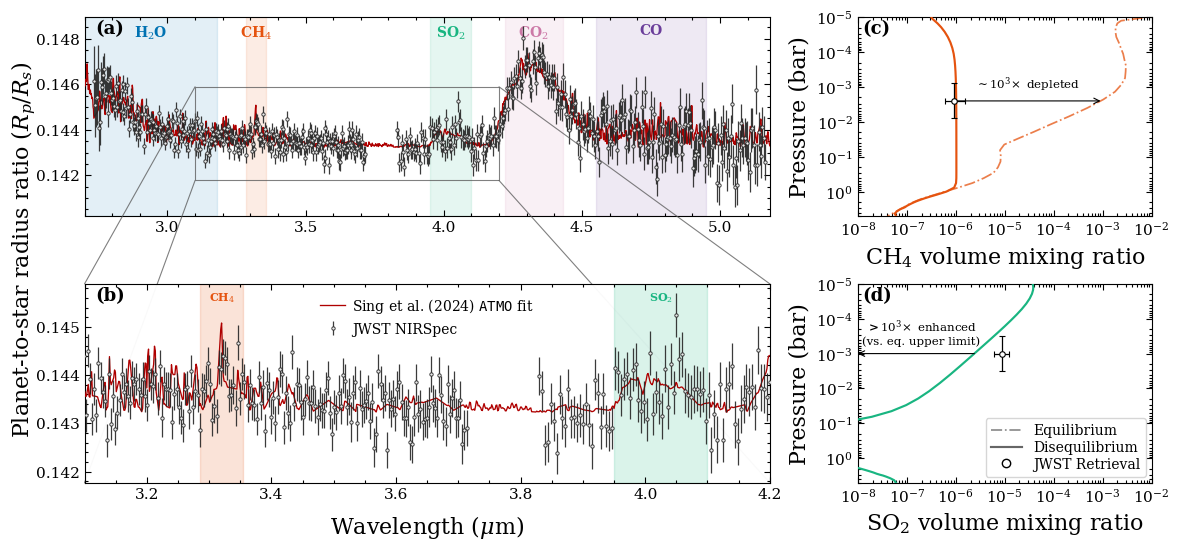

In [12]:
# Reload the local plotting module so edits are not hidden by Jupyter's import cache.
import importlib
import FINESST_WASP107b_Disequilibrium_Motivation_Plot as figure_module
figure_module = importlib.reload(figure_module)

fig, axes, metadata = figure_module.make_figure(products, config)
outputs = figure_module.save_figure(fig, metadata, config)

ratio_record = metadata[
    'ch4_equilibrium_to_retrieved_ratio_at_annotation_pressure'
]
print(
    'Equilibrium/retrieved CH4 ratio at '
    f"log10(P/bar)={ratio_record['log10_pressure_bar']}: "
    f"{ratio_record['ratio']:.1f}"
)
so2_bound = metadata['equilibrium_so2']['median_retrieved_to_figure_floor_ratio']
print(
    'Retrieved SO2 / published Figure 3 plotting floor: '
    f">{so2_bound:.1f} (graphical lower bound, not an equilibrium model value)"
)
display(fig)
plt.close(fig)

## Output locations

In [13]:
for product, path in outputs.items():
    print(f'{product.upper()}: {path}')

PDF: /home/eraul/wisconsin/work/atmosphere_research_2026/POSEIDON/run/POSEIDON_output/WASP-107b/plots/FINESST/figure2_WASP107b_disequilibrium_motivation.pdf
